In [16]:
import pickle
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [17]:
best_models = [
                # 'code-deepseek_6b-ndelays_4-look_ahead_by_10',
                'code-deepseek_6b-ndelays_10-look_ahead_by_0',
            #    'code-codegemma_7b-ndelays_4-look_ahead_by_10',
            #    'code-codegemma_7b-ndelays_16-look_ahead_by_0',
            #    'prose-codegemma_7b-ndelays_10-look_ahead_by_5',
            #    'prose-deepseek_6b-ndelays_20-look_ahead_by_10'
                # 'prose-deepseek_6b-ndelays_4-look_ahead_by_10',
                'prose-starcoder2_7b-ndelays_16-look_ahead_by_3'
            ]

with open('/data/zachkaras/fmri_model_data/intermediate_results/enrichment_analysis_results.pkl', 'rb') as f:
    enrichment_results = pickle.load(f)
    
with open("/data/zachkaras/fmri_model_data/intermediate_results/all_results.pkl", 'rb') as f:
    records = pickle.load(f)

In [18]:
participant_means = {}

for m in best_models:
    
    participant_means[m] ={}
    parts = m.split('-')
    task, model, delays, look_ahead = parts[0], parts[1], parts[2], parts[3]

    mask = ((records['task'] == task) & 
            (records['model'] == model) & 
            (records['ndelays'] == delays) &
            (records['look_ahead'] == look_ahead))
    
    for p, df in records[mask].groupby(['participant']):
        p = p[0]
        layer_mean = df['top_voxel_vals'].explode().mean()
        participant_means[m][p] = layer_mean

In [19]:
enrichments = {m:{} for m in best_models}

for (model, p), df in enrichment_results.groupby(['model', 'participant']):
    average_enrichment = np.mean(df['num_sig_parcels']) # averaging across layers
    m = df['model'].unique().item()

    enrichments[m][p] = average_enrichment

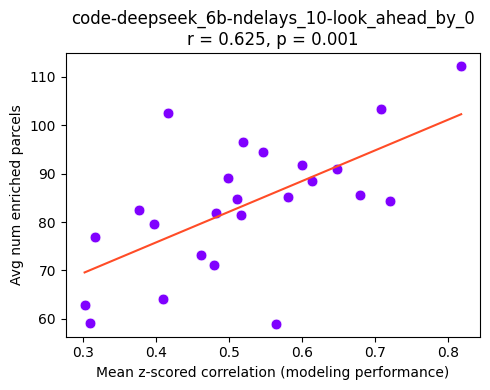

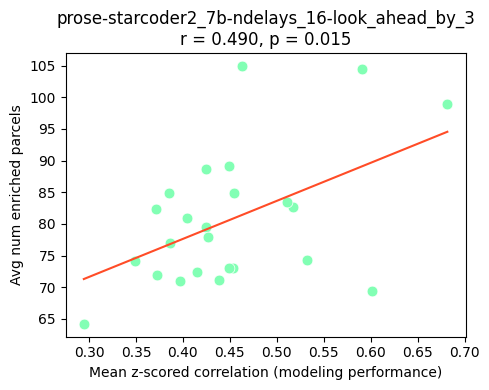

In [20]:
task_colors = {'code': '#8000ffff', 'prose': '#82ffb4'}

for m in best_models:
    parts = m.split('-')
    task = parts[0]
    color = task_colors[task]
    
    perf = participant_means[m]   # {pid: float}
    enrich = enrichments[m]       # {pid: float}

    common_pids = [pid for pid in perf if pid in enrich]
    x = np.array([perf[pid] for pid in common_pids])
    y = np.array([enrich[pid] for pid in common_pids])

    r, p = stats.pearsonr(x, y)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(x, y, color=color, edgecolors='white', linewidths=0.5, s=60)

    m_fit, b_fit = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m_fit * x_line + b_fit, color='#ff4c27', linewidth=1.5)

    ax.set_xlabel('Mean z-scored correlation (modeling performance)')
    ax.set_ylabel('Avg num enriched parcels')
    ax.set_title(f"{m}\nr = {r:.3f}, p = {p:.3f}")

    plt.tight_layout()
    # plt.savefig(f"results/enrichment_corr_{m}.png", dpi=150, bbox_inches='tight')
    plt.show()
